# Predicting Stock Prices with Deep Neural Networks

#### HEMANT THAPA

As financial markets are inherently driven by historical sequences of equity prices, an increasing number of quantitative researchers and finance professionals are turning to Long Short-Term Memory (LSTM) networks to model and predict market trends. In this project, we will explore the complete machine learning lifecycle involved in developing an LSTM model to forecast stock market prices, utilizing Python with PyTorch.



In [1]:
import torch
import torch.nn as nn
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

In [2]:
# configuration
config = {
    "yfinance": {
        "symbol": "IBM",
        "start_date": "1991-11-01",
        "end_date": "2024-01-01",
    },
    "data": {
        "window_size": 30,  
        "train_split_size": 0.80,
    },
    "plots": {
        "xticks_interval": 90,
        "color_actual": "#001f3f",
        "color_pred_train": "#3D9970",
        "color_pred_val": "#0074D9",
    },
    "model": {
        "input_size": 1,
        "num_lstm_layers": 2,  
        "lstm_size": 64,      
        "dropout": 0.4,        
    },
    "training": {
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "batch_size": 64,      
        "num_epoch": 100,       
        "learning_rate": 0.001,  
        "scheduler_step_size": 10, 
        "weight_decay": 1e-4, 
    }
}


In [3]:
# data acquisition
def download_data(config):
    data = yf.download(config["yfinance"]["symbol"], start=config["yfinance"]["start_date"], end=config["yfinance"]["end_date"])
    data_date = data.index
    data_close_price = data['Close'].values

    num_data_points = len(data_date)
    display_date_range = f"from {data_date[0].strftime('%Y-%m-%d')} to {data_date[-1].strftime('%Y-%m-%d')}"
    print(f"Number of data points: {num_data_points}, Date range: {display_date_range}")

    return data_date, data_close_price, num_data_points, display_date_range

In [4]:
# normalization
class Normalizer():
    def __init__(self):
        self.scaler = StandardScaler()

    def fit_transform(self, x):
        normalized_x = self.scaler.fit_transform(x.reshape(-1, 1)).reshape(-1)
        return normalized_x

    def inverse_transform(self, x):
        return self.scaler.inverse_transform(x.reshape(-1, 1)).reshape(-1)

In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = data
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        X = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [6]:
def create_datasets(normalized_data, window_size, split_ratio):
    num_train = int(len(normalized_data) * split_ratio)
    train_data = normalized_data[:num_train]
    val_data = normalized_data[num_train - window_size:]
    train_dataset = TimeSeriesDataset(train_data, window_size)
    val_dataset = TimeSeriesDataset(val_data, window_size)
    return train_dataset, val_dataset

In [7]:
# LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, lstm_size, num_lstm_layers, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, lstm_size, num_lstm_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(lstm_size, 1)

    def forward(self, x):
        h_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c_0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h_0, c_0))
        out = self.fc(out[:, -1, :])
        return out

In [8]:
# training function
def train_model(model, train_loader, val_loader, num_epoch):
    device = torch.device(config["training"]["device"])
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=config["training"]["scheduler_step_size"], gamma=0.1)

    train_losses = []
    val_losses = []

    for epoch in range(num_epoch):
        model.train()
        epoch_loss = 0
        for X_batch, Y_batch in train_loader:
            X_batch, Y_batch = X_batch.unsqueeze(-1).to(device), Y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs.squeeze(), Y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))
        scheduler.step()

        # Validation
        model.eval()
        val_loss = 0
        predictions = []
        true_values = []
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch, Y_batch = X_batch.unsqueeze(-1).to(device), Y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs.squeeze(), Y_batch)
                val_loss += loss.item()

                # Store predictions and true values
                predictions.extend(outputs.cpu().numpy())
                true_values.extend(Y_batch.cpu().numpy())

        val_losses.append(val_loss / len(val_loader))
        print(f'Epoch {epoch + 1}/{num_epoch}, Training Loss: {train_losses[-1]}, Validation Loss: {val_losses[-1]}')

    return np.array(predictions), np.array(true_values), train_losses, val_losses


In [9]:
# line plot function
def plot_data(data_date, data_close_price, config, display_date_range, predictions=None, true_values=None):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(data_date, data_close_price, color=config["plots"]["color_actual"], label='Actual Data')
    if predictions is not None and true_values is not None:
        pred_dates = data_date[-len(predictions):]
        ax.plot(pred_dates, predictions, color=config["plots"]["color_pred_val"], label='Predictions')
        ax.plot(pred_dates, true_values, color=config["plots"]["color_pred_train"], linestyle='--', label='True Validation Data')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.grid(True, ls='--', alpha=0.5)
    plt.title(f"Daily Close Price for {config['yfinance']['symbol']}, {display_date_range}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
data_date, data_close_price, num_data_points, display_date_range = download_data(config)

[*********************100%%**********************]  1 of 1 completed
Number of data points: 8100, Date range: from 1991-11-01 to 2023-12-29


In [11]:
data_date[:5]

DatetimeIndex(['1991-11-01', '1991-11-04', '1991-11-05', '1991-11-06',
               '1991-11-07'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [12]:
data_close_price[:5]

array([23.51218987, 23.1835556 , 23.09392929, 23.09392929, 23.87069893])

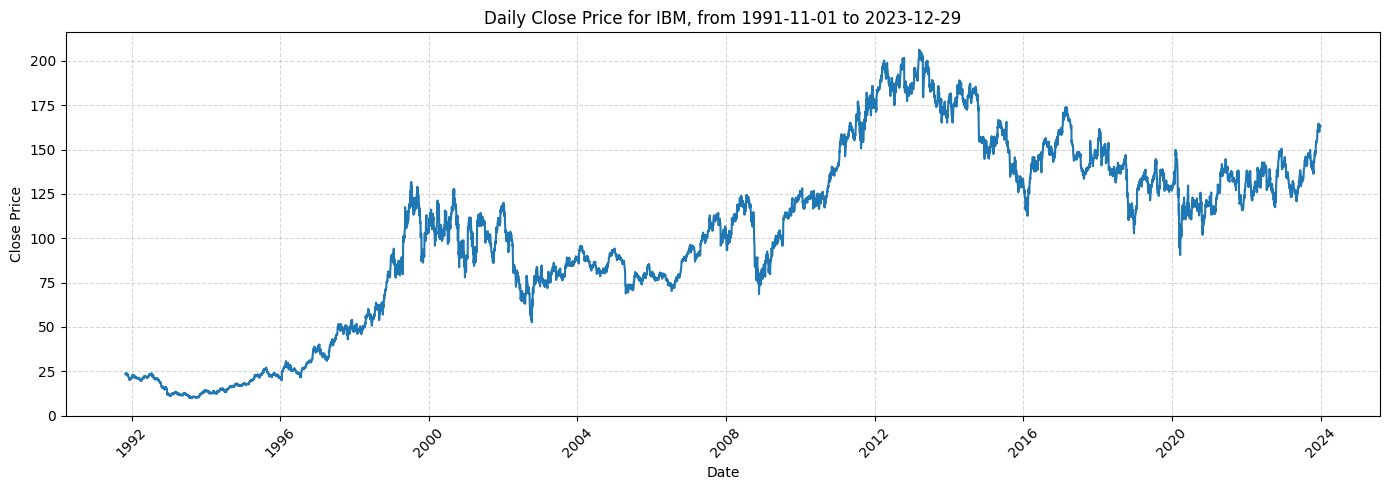

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
plt.plot(data_date, data_close_price)
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, ls='--', alpha=0.5)
plt.title(f"Daily Close Price for {config['yfinance']['symbol']}, {display_date_range}")
plt.tight_layout()
plt.show()

In [14]:
num_data_points

8100

In [15]:
display_date_range

'from 1991-11-01 to 2023-12-29'

In [16]:
# normalize the data
scaler = Normalizer()
normalized_data_close_price = scaler.fit_transform(data_close_price)

In [17]:
window_size = config["data"]["window_size"]
split_ratio = config["data"]["train_split_size"]
train_dataset, val_dataset = create_datasets(normalized_data_close_price, window_size, split_ratio)

In [18]:
# data loaders
batch_size = config["training"]["batch_size"]
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# train the model
model = LSTMModel(config["model"]["input_size"], config["model"]["lstm_size"], config["model"]["num_lstm_layers"], config["model"]["dropout"])
num_epoch = config["training"]["num_epoch"]
predictions, true_values, train_losses, val_losses = train_model(model, train_loader, val_loader, num_epoch)

Epoch 1/100, Training Loss: 0.18287095707831996, Validation Loss: 0.006632507545873523
Epoch 2/100, Training Loss: 0.0074761671585833085, Validation Loss: 0.007240567965289721
Epoch 3/100, Training Loss: 0.006688481798432399, Validation Loss: 0.006281487357157927
Epoch 4/100, Training Loss: 0.0063884631629184925, Validation Loss: 0.006598178449516686
Epoch 5/100, Training Loss: 0.005944125681636062, Validation Loss: 0.008206135127693415
Epoch 6/100, Training Loss: 0.005809540911070486, Validation Loss: 0.005633342276828794
Epoch 7/100, Training Loss: 0.005576223310193803, Validation Loss: 0.005538297682785644
Epoch 8/100, Training Loss: 0.005356918960477751, Validation Loss: 0.005460716757135322
Epoch 9/100, Training Loss: 0.005249413161418668, Validation Loss: 0.0050230830272014896
Epoch 10/100, Training Loss: 0.005180107920642684, Validation Loss: 0.004861080929493675
Epoch 11/100, Training Loss: 0.004647629413901284, Validation Loss: 0.004664573276666208
Epoch 12/100, Training Loss:

In [19]:
# inverse transform predictions and true values
predictions = scaler.inverse_transform(predictions)
true_values = scaler.inverse_transform(true_values)

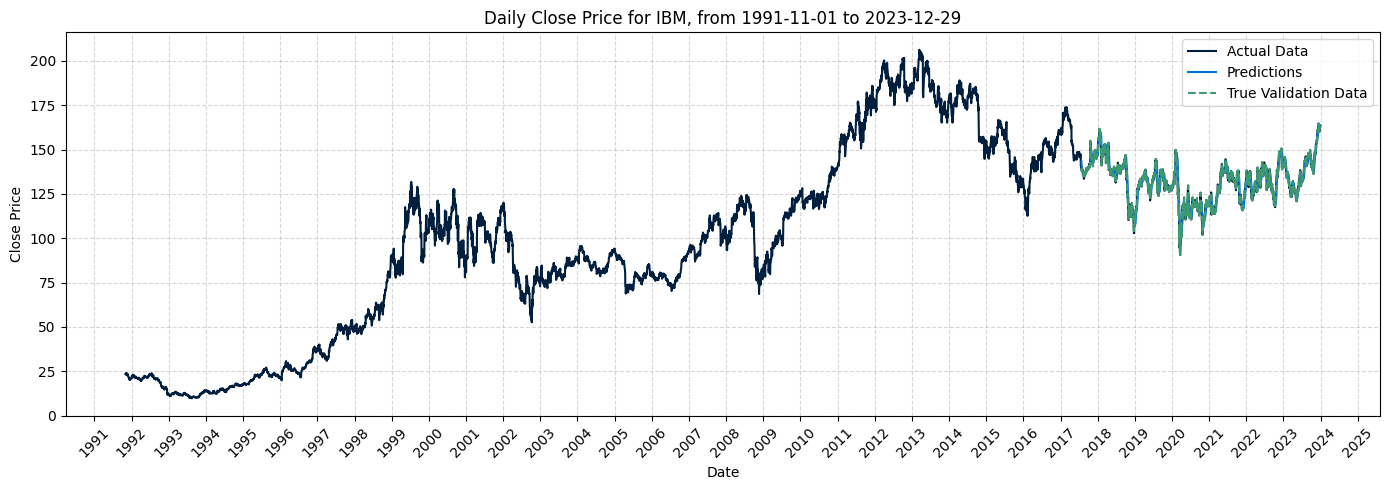

In [20]:
# predictions
plot_data(data_date, data_close_price, config, display_date_range, predictions=predictions, true_values=true_values)

## References:

https://www.alphavantage.co/stock-prediction-deep-neural-networks-lstm/